# Impact of $m_5$ map generation

The goal of this notebook is to generate tha data to study the impact of $m_5$ when no dipole or clustering is inected.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import fitsio

from simulMap import *
from fitMap import *
from utile_fitsFile import *
from lumMag_sampling import *
from mappers import CountMapper, DepthMapper
from spectra import Spectrum
from generators import Generator

In [2]:
#sources:
NSource_px_th = int(1e6)
#print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Theorical number of sources in one pixel : 1000000


## $m_5$ magnitude

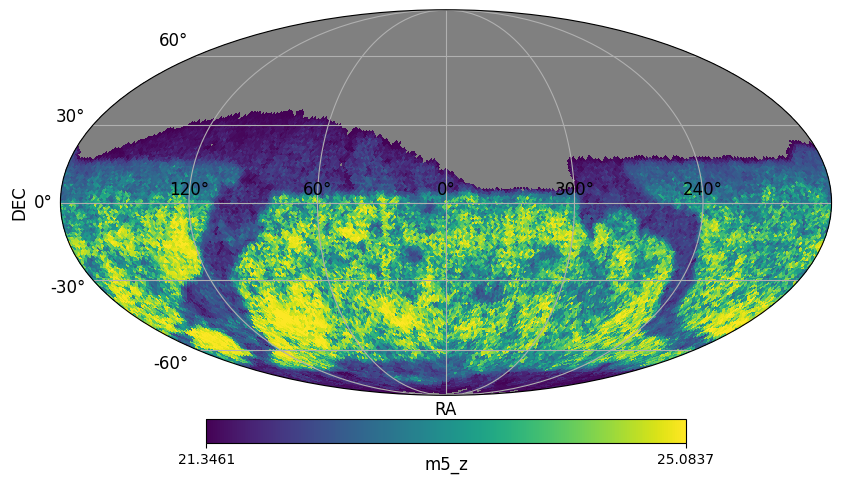

In [3]:
DIR_m5 = '../data/'
FILE = DIR_m5 + "baseline_v5.0.0_10yrs_summary.hdf5"
dm = DepthMapper.read_hdf(FILE)
dm.select_year(1)
band = 'z'
dm.select_band(band)
dm.set_mask()
dm.plot()

## Reference spectrum

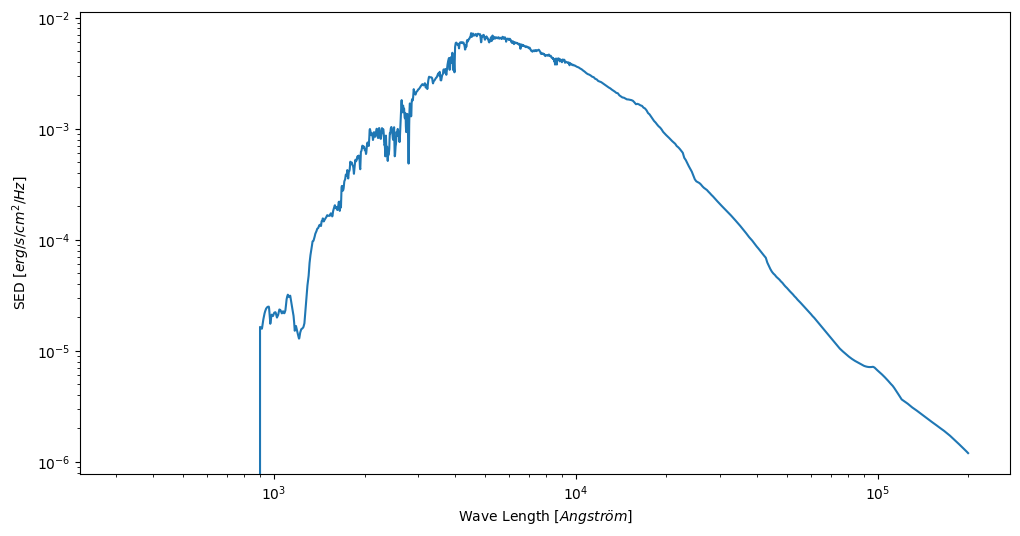

In [4]:
DIR_SED = "../data/data SED/SED GAL/COSMOS/"
FILE_SED = "Ell1_A_0"
file = DIR_SED + FILE_SED + ".sed"
refSpectum = Spectrum.read_sed(file)
refSpectum.plot(loglog=True, title="");

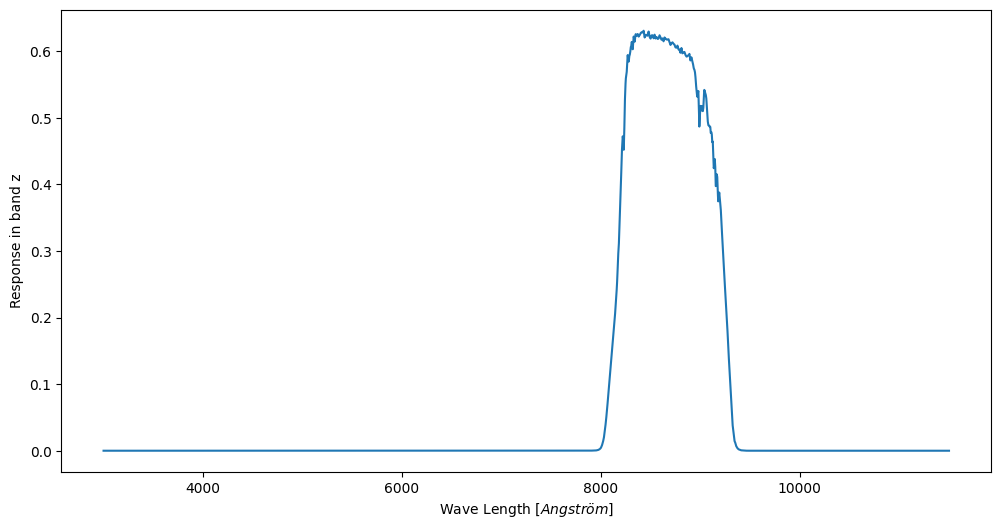

In [5]:
file_band = f"../data/data LSST/total_{band}.dat"
responseSpectrum = Spectrum.read_sed(file_band, yname=f"Response in band {band}", yunit="")
responseSpectrum.wavelength = responseSpectrum.wavelength*10
responseSpectrum.plot(loglog=False, title="");

In [6]:
_, response = refSpectum.get_surrounding(responseSpectrum)
response = response.mean(axis=0)
L_bandRatio = refSpectum.ratio_integrate(response)
print(f"SED band {band} ratio : {L_bandRatio}")

SED band z ratio : 0.023790153369038326


## Importing $N_{th}$ map

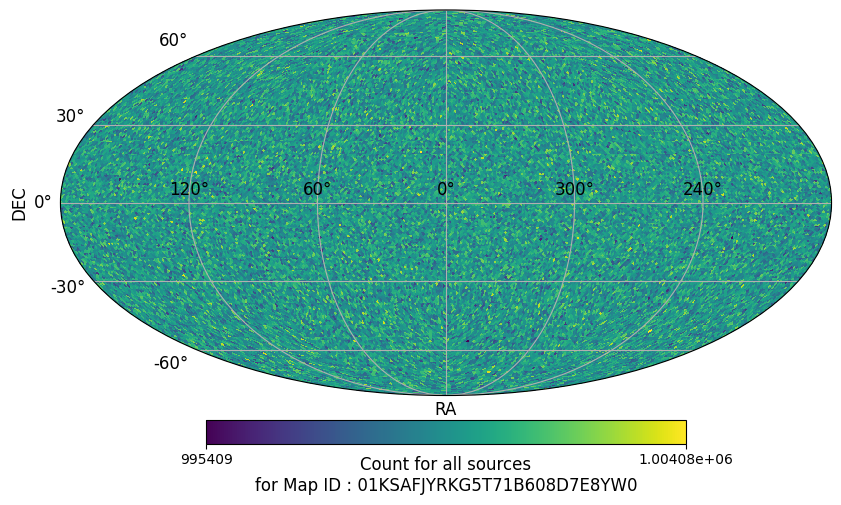

In [7]:
DIR_Nth = "Catalog_m5/Catalog_m5Nth/"
sufix = "NthPoisson"
file_Nth = DIR_Nth + sufix + '.fits'

count_thMapper = CountMapper.read_map_fits(file_Nth, idx=0, HDU='Nth_1e6', unitSuffix="all sources") #first Nth map
count_thMapper.plot()

## Importing bolometric data file

In [8]:
DIR_cat = "Catalog_m5/Catalog_m5Ratio/"
sufix = "testRatio"
file_cat = DIR_cat + sufix + '.fits'

dataN, data_ID = read_lumMag_fits(file_cat, 0, L_bandRatio=L_bandRatio, to_band=band)
dataN

z,dL,L,M,m,L_z,M_z,m_z
,Mpc,solLum,,,solLum,solLum,solLum
float64,float64,float64,float64,float64,float64,float64,float64
1.014542326432987,7027.145682378759,30645546.713645894,-13.885918433823983,30.34797635193339,729062.2563956643,-9.826911538403523,34.40698324735385
0.7363209110631574,4734.488512540824,2677336894.761015,-18.73925755696431,24.63710777876085,63694255.34694937,-14.68025066154385,28.69611467418131
0.8083768640688359,5309.647095345624,25510623.16818487,-13.686802668986099,29.938525614728903,606901.6377108605,-9.627795773565639,33.99753251014936
0.45044390448429966,2612.4876463369646,15778842.982701296,-13.165187886180528,28.920083341203785,375381.094544438,-9.106180990760068,32.979090236624245
0.4987659532367315,2950.87540205728,12663883.576797798,-12.926417273155431,29.423337087896755,301275.73253966524,-8.867410377734972,33.482343983317215
0.8516695348807279,5661.8510749809375,125990258.58744024,-15.42084241824489,28.34394979089506,2997327.574800001,-11.36183552282443,32.40295668631552
0.8438439425794242,5597.832695085243,794616713.3066007,-17.42039423851022,26.319705333348903,18904053.47916519,-13.361387343089755,30.378712228769366
0.32696617180733534,1792.138316712811,169180714.42846972,-15.740877136493586,25.5259804902122,4024835.1433367697,-11.681870241073126,29.584987385632658


## Ratio and detected map creation

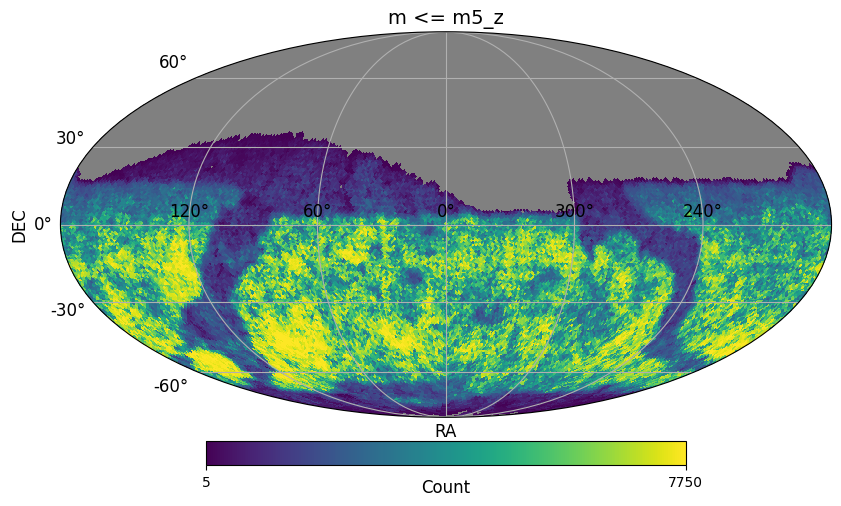

In [9]:
_, hpmap_band = dm._get_band_map(band)
NSource_px = cut_m52map(dataN[f"m_{band}"], hpmap_band)
countMapper = CountMapper.from_map(NSource_px)
countMapper.set_mask()
countMapper.plot("Masked", norm="hist", title= f"m <= m5_{band}")

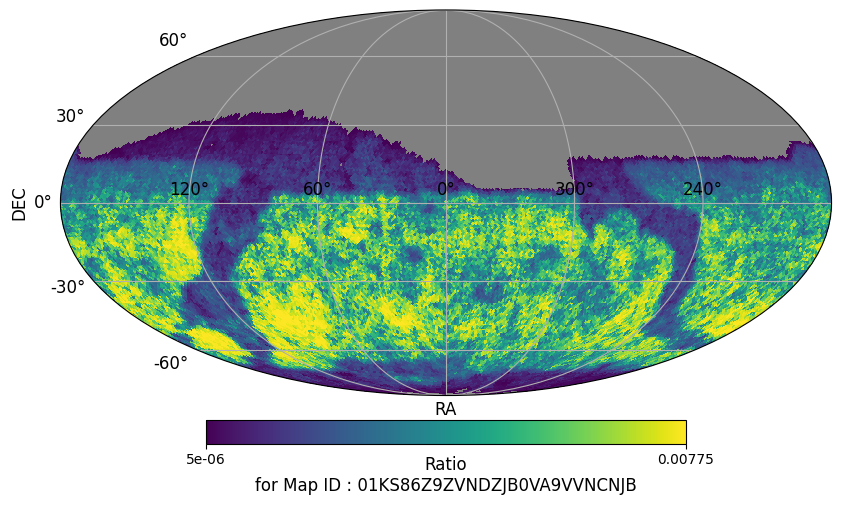

In [10]:
ratioMapper = CountMapper.from_map(countMapper.map/NSource_px_th)
ratioMapper._set_instance_settingsPlot(unit = 'Ratio')
ratioMapper.set_mask()
ratioMapper.set_mapID(data_ID)
ratioMapper.plot("Masked", norm="hist")

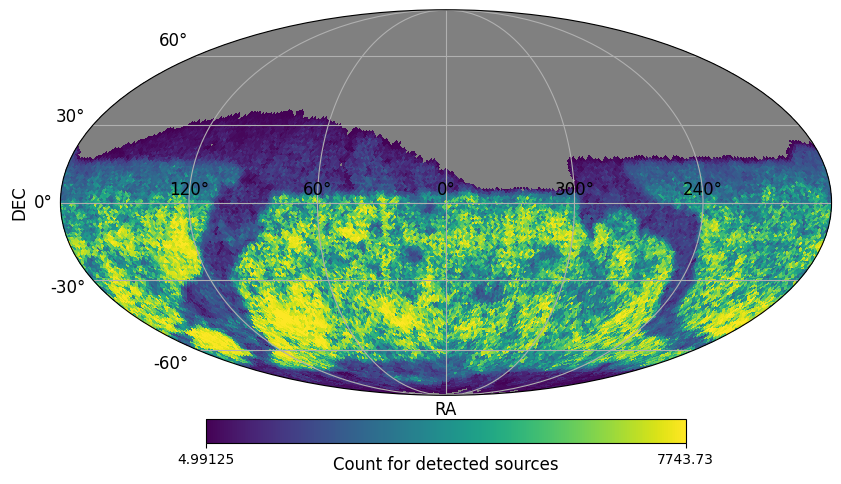

In [11]:
countDetectedMapper = CountMapper.from_map(count_thMapper.map * ratioMapper.map)
countDetectedMapper._set_suffixTextPlot(unit = "detected sources")
countDetectedMapper.set_mask()
countDetectedMapper.plot("Masked", norm="hist")

## Study of $m_5$ effect

In [12]:
def get_m5Monop(M=NSource_px_th, poissNoise=False):
    countObservedMapper = CountMapper.from_map(countDetectedMapper.map)
    # if poissNoise: countObservedMapper = countDetectedMapper.get_poisson_noise()
    # else: countObservedMapper = CountMapper.from_map(countDetectedMapper.map)
    hpmapMasked = dm._select_useMap(f'{band}Masked')
    countObservedMapper.set_mask(hpmapMasked.mask)

    countCorrectedMapper = CountMapper.from_map(countObservedMapper.map / ratioMapper.map)
    countCorrectedMapper.fillna()
    if poissNoise: countCorrectedMapper = countCorrectedMapper.get_poisson_noise()
    countCorrectedMapper._set_suffixTextPlot(unit = f"corrected sources\nmonopole N* = {M}")
    countCorrectedMapper.set_mask()

    return countCorrectedMapper, countObservedMapper


# poissNoise = True

# Ntrial = 1000
# map_m5, fit_m5, map_IDs = [], [], []
# for i in range(Ntrial):
#     if i % 100 == 0: print(f'i = {i}', end = '\t')
#     countCorrectedMapper, countObservedMapper = get_m5Monop(M=NSource_px_th, poissNoise=poissNoise)
#     map_m5.append(countCorrectedMapper.map)
#     map_IDs.append(countObservedMapper.ID)
#     d = estimate_dipole_mle(countCorrectedMapper.mapMasked)
#     fit_m5.append(d)

# dfMaps = {'Map_ID': np.array(map_IDs, dtype='S26'), 'Map': np.array(map_m5)}
# dfMC = {'Map_ID': np.array(map_IDs, dtype='S26'),'A' : np.linalg.norm(fit_m5, axis=1)}
# dfMC['Dx'], dfMC['Dy'], dfMC['Dz'] = tuple(np.array(fit_m5).T)

# print("\nMean:", np.mean(fit_m5, axis=0))
# print("Std :", np.std(fit_m5, axis=0))
# print("Amplitude:", np.mean(np.linalg.norm(fit_m5, axis=1)))

In [13]:
# dfMC = pd.DataFrame(dfMC)
# dfMC

In [14]:
# countCorrectedMapper.fit_dipole('Masked', init=(1e6, 1, 100, 0))

In [15]:
def get_compute(M=NSource_px_th, init=(1e6, 1, 100, 0), poissNoise=False):
    monopMapper, countObservedMapper = get_m5Monop(M=M, poissNoise=poissNoise)
    m = monopMapper.fit_dipole("Masked", init, plot_fig=False, plot_map=False, verbose=False, fixed=fixed)
    
    add_param = {"Nth_ID": count_thMapper.ID, "Ratio_ID": ratioMapper.ID, "BAND": band}
    add_param = get_add_param_minuit(m, M, 0, np.nan, np.nan, add_param=add_param)
    
    mapID = monopMapper.ID
    dic_param = get_dicParam_minuit(m, mapID, add_param=add_param)
    return m, dic_param, monopMapper



poissNoise = True

M, init = NSource_px_th, (NSource_px_th, 1, 100, 0)
fixed = []

dfMinuit, mapList, IDlist = [], [], []

Ntrial = 100

for i in range(Ntrial):
    if i % 10 == 0: print(f'i = {i}', end = '\t')
    m, dic_param, monopMapper = get_compute(M=M, init=init, poissNoise=poissNoise)
    dfMinuit.append(dic_param)
    mapList.append(monopMapper._select_useMap(""))
    IDlist.append(str(monopMapper.ID))
print('\nFit complete.')

dfMinuit = pd.concat(dfMinuit, ignore_index=True)
dicMaps = get_dicMaps(IDlist, mapList)
dfMinuit

i = 0	

/tmp/ipykernel_82158/1452470288.py:8: RuntimeWarning: invalid value encountered in divide
  countCorrectedMapper = CountMapper.from_map(countObservedMapper.map / ratioMapper.map)


i = 10	i = 20	i = 30	i = 40	i = 50	i = 60	i = 70	i = 80	i = 90	
Fit complete.


,Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,...,dec_limit_0,dec_limit_1,valid,Nth_ID,Ratio_ID,BAND,N*_true,A_true,ra_true,dec_true
0,01KTBQZWCJZB4E42EC0G52VJ91,999981.628401,1000000.0,6.956317,False,0.0,inf,0.000022,1.0,0.000009,...,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,z,1000000,0,NaN,NaN
1,01KTBR02H0CJFC79YNPRRRPQK9,999984.098018,1000000.0,7.095900,False,0.0,inf,0.000014,1.0,0.000009,...,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,z,1000000,0,NaN,NaN
2,01KTBR0A89023SB0MR1R5FV2SD,999992.445141,1000000.0,6.876597,False,0.0,inf,0.000023,1.0,0.000012,...,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,z,1000000,0,NaN,NaN
3,01KTBR0J2XHY0DCGYFV0SA4FAC,999993.109968,1000000.0,6.998720,False,0.0,inf,0.000042,1.0,0.000013,...,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,z,1000000,0,NaN,NaN
4,01KTBR0RYVRP2K8E17QTYJB6CN,999984.344193,1000000.0,7.089326,False,0.0,inf,0.000030,1.0,0.000010,...,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,z,1000000,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,01KTBRKQPPRCW0XJG4DAP2P3S6,999993.162099,1000000.0,6.974700,False,0.0,inf,0.000034,1.0,0.000012,...,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,z,1000000,0,NaN,NaN
96,01KTBRKX2T06P5X61B35FX8GPD,999995.214915,1000000.0,7.096747,False,0.0,inf,0.000032,1.0,0.000011,...,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,z,1000000,0,NaN,NaN
97,01KTBRM2YHXCE48RYQD4C0T6NJ,999987.801616,1000000.0,6.993221,False,0.0,inf,0.000022,1.0,0.000011,...,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,z,1000000,0,NaN,NaN
98,01KTBRM9F2HYBXVQFFVZX2F7P8,999999.636241,1000000.0,7.098388,False,0.0,inf,0.000033,1.0,0.000013,...,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,z,1000000,0,NaN,NaN


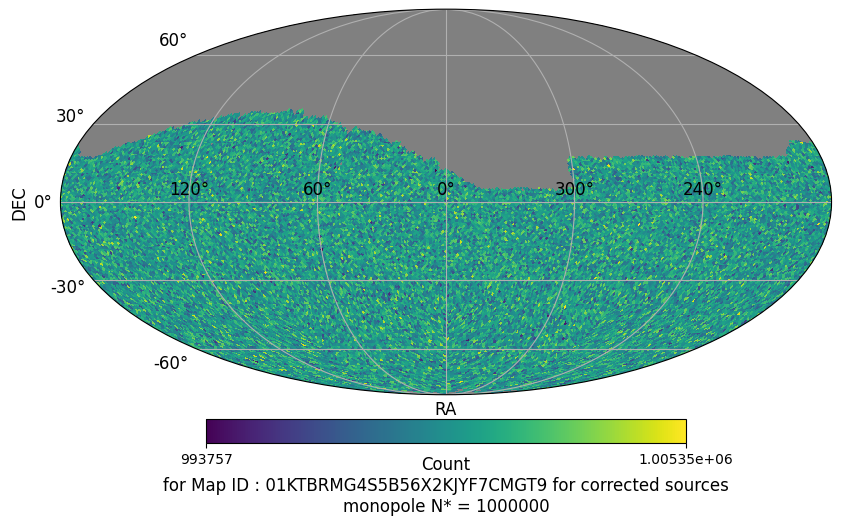

In [16]:
monopMapper.plot('Masked')

#### Saving data

In [17]:
output_path = "Fit_m5/m5_NoDipole/m5_NoDipole_"
if poissNoise: suffix_poiss = "_poissVar"
else: suffix_poiss = ""
suffix = "Footprint_study"
outputfile = output_path + suffix + suffix_poiss +".fits"

HDU_target=f'BAND_{band}'

header_global = {'MAP_TYPE': 'm5_Corrected', 'INJECT_DIPOLE': False, 'INJECT_CLUSTERING': False, 'POISSON_NOISE' : poissNoise}
if poissNoise: dicMaps_fiterd = get_save_dicMaps(dicMaps, outputfile, HDU_target=f'MAPS_{HDU_target}', header_global=header_global)
dfMinuit_filtered = get_save_fit_dfMinuit(dfMinuit, outputfile, HDU_target=HDU_target, header_global=header_global)

Coulndn't find HDU MAPS_BAND_z in the data ; creating one.
Saving maps in Fit_m5/m5_NoDipole/m5_NoDipole_Footprint_study_poissVar.fits
Saving complete.
Coulndn't find HDU BAND_z in the data ; creating one.
Saving Dataframe results in Fit_m5/m5_NoDipole/m5_NoDipole_Footprint_study_poissVar.fits
Saving complete.


/home/victoria/Travaux_Jupyter_Ububtu/M2Stage_JohannGit/M2_Stage_Code/Simulation/fitMap.py:339: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(False, inplace=True)


In [18]:
dfMinuit['A'].describe()

count    1.000000e+02
mean     2.576933e-05
std      1.045018e-05
min      2.794995e-11
25%      1.989267e-05
50%      2.568595e-05
75%      3.076117e-05
max      6.199535e-05
Name: A, dtype: float64